In [2]:
from resources.imports import *

# RBF Interpolation

In [3]:
def phi(x):
    F = np.sin(2 * np.pi * x) * np.cos(5 * np.pi * x)
    return F

def gaussian(x1, x2, l = 1):
    f = np.exp(-(x1 - x2) ** 2 / (2 * l ** 2))
    return f

def kernel_matrix(X, l = 1, f = gaussian):
    G = np.zeros([len(X), len(X)])
    for i in range(len(X)):
        for j in range(len(X)):
            G[i, j] = f(X[i], X[j], l)
    return G

def rbf_model(G, d):
    m = np.dot(np.linalg.inv(G), d)
    return m

def rbf_predict(x, X, m, l = 1, f = gaussian):
    S = np.zeros(len(x))
    for i in range(len(m)):
        S = S + m[i] * f(x, X[i], l)
    return S

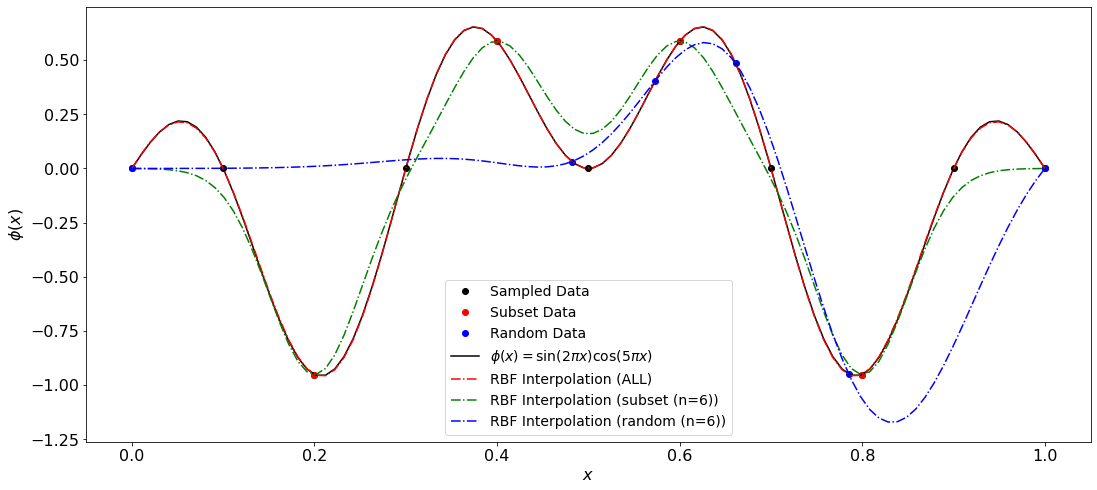

In [7]:
# Sample 10 values of X and phi.
N = 10
X = np.arange(0, N + 1, 1) / N
d = phi(X)

X_ = np.arange(2, 9, 2) / 10
d_ = phi(X_)

Xr = np.array([0.0] + [random.random() for i in range(4)] + [1.0])
dr = phi(Xr)
# Gaussian length scale.
L = 1 / 9
L_ = 1 / 20
Lr = 1 / 9

# Calculate the kernel matrix G
G = kernel_matrix(X, L, gaussian)
G_ = kernel_matrix(X_, L_, gaussian)
Gr = kernel_matrix(Xr, Lr, gaussian)

# Invert d = Gm for the model parameters.
m = rbf_model(G, d)
m_ = rbf_model(G_, d_)
mr = rbf_model(Gr, dr)

# Using m, interpolate phi for all values in x ∈ [0, 1].
x = np.linspace(0, 1, 100)
S = rbf_predict(x, X, m, L, gaussian)
S_ = rbf_predict(x, X_, m_, L_, gaussian)
Sr = rbf_predict(x, Xr, mr, Lr, gaussian)

# Plot the results.
plt.figure(figsize = [18, 8])
plt.plot(X, d, "ko", label="Sampled Data")     # Sampled discrete data points of phi.
plt.plot(X_, d_, "ro", label="Subset Data")     # Sampled discrete data points of phi.
plt.plot(Xr, dr, "bo", label="Random Data")     # Sampled discrete data points of phi.

plt.plot(x, phi(x), "k", label="$\phi(x) = \sin(2 \pi x) \cos(5 \pi x)$") # True "continuous" values of phi.
plt.plot(x, S, "r-.", label="RBF Interpolation (ALL)")    # # Interpolated values of phi.
plt.plot(x, S_, "g-.", label="RBF Interpolation (subset (n=6))")     # Sampled discrete data points of phi.
plt.plot(x, Sr, "b-.", label="RBF Interpolation (random (n=6))")     # Sampled discrete data points of phi.

plt.legend(fontsize = 14)
plt.xlabel("$x$", fontsize = 16)
plt.ylabel("$\phi(x)$", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()


# # Plots the weighted Gaussians used in the interpolation model.
# plt.figure(1, figsize = [18, 4])
# for i in range(len(m)):
#     plt.plot(m[i] * gaussian(x, X[i], L))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

# plt.figure(2, figsize = [18, 4])
# for i in range(len(m_)):
#     plt.plot(m_[i] * gaussian(x, X_[i], L_))
# plt.legend(range(len(m_)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

# plt.figure(3, figsize = [18, 4])
# for i in range(len(mr)):
#     plt.plot(mr[i] * gaussian(x, Xr[i], Lr))
# plt.legend(range(len(mr)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

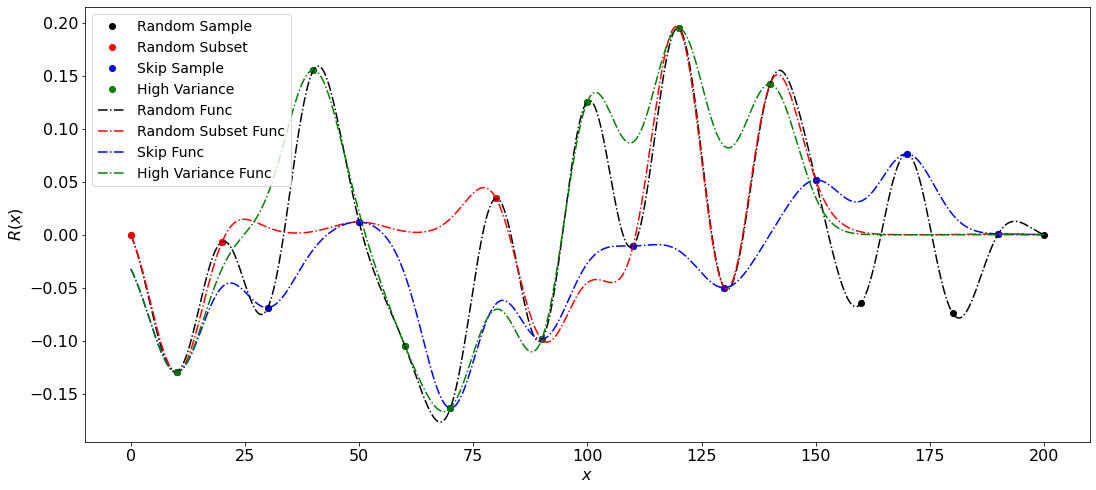

Sample size : 21
 Subset   : 56.99999999999999%
 Skip     : 47.62%
 Variance : 38.1%

Mean Absolute Error:
 Subset   : 0.043
 Skip     : 0.0525
 Variance : 0.0353


In [37]:
N = 200
X = np.arange(0, N + 1, 10)
d = np.array([0.5]+[random.random() for i in range(len(X)-2)]+[0.5])*0.4 - 0.2

X_, d_ = zip(*random.sample(list(zip(X, d)), int(0.6*len(X))))

X_skip = [X[i] for i in range(1, len(X), 2)]
d_skip = [d[i] for i in range(1, len(d), 2)]

mu = np.mean(d)
var = np.std(d)

dv = np.array([dd for i,dd in enumerate(d) if dd > mu+var or dd < mu-var])
dv_ind = [d.tolist().index(i) for i in dv if i in d]
Xv = X[dv_ind]

# Gaussian length scale.
L = 6

# Calculate the kernel matrix G
G = kernel_matrix(X, L, gaussian)
G_ = kernel_matrix(X_, L, gaussian)
Gv = kernel_matrix(Xv, L, gaussian)
G_skip = kernel_matrix(X_skip, L, gaussian)

# Invert d = Gm for the model parameters.
m = rbf_model(G, d)
m_ = rbf_model(G_, d_)
mv = rbf_model(Gv, dv)
m_skip = rbf_model(G_skip, d_skip)

# Using m, interpolate phi for all values in x ∈ [0, 1].
x = np.linspace(0, 200, 1000)
S = rbf_predict(x, X, m, L, gaussian)
S_ = rbf_predict(x, X_, m_, L, gaussian)
Sv = rbf_predict(x, Xv, mv, L, gaussian)
S_skip = rbf_predict(x, X_skip, m_skip, L, gaussian)

# Plot the results.
plt.figure(figsize = [18, 8])
plt.plot(X, d, "ko", label="Random Sample")     # Sampled discrete data points of phi.
plt.plot(X_, d_, "ro", label="Random Subset")     # Sampled discrete data points of phi.
plt.plot(X_skip, d_skip, "bo", label="Skip Sample")     # Sampled discrete data points of phi.
plt.plot(Xv, dv, "go", label="High Variance")     # Sampled discrete data points of phi.
plt.plot(x, S, "k-.", label="Random Func")    # # Interpolated values of phi.
plt.plot(x, S_, "r-.", label="Random Subset Func")     # Sampled discrete data points of phi.
plt.plot(x, S_skip, "b-.", label="Skip Func")     # Sampled discrete data points of phi.
plt.plot(x, Sv, "g-.", label="High Variance Func")     # Sampled discrete data points of phi.

plt.legend(fontsize = 14)
plt.xlabel("$x$", fontsize = 16)
plt.ylabel("$R(x)$", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()


# # Plots the weighted Gaussians used in the interpolation model.
# plt.figure(1, figsize = [18, 4])
# for i in range(len(m)):
#     plt.plot(m[i] * gaussian(x, X[i], L))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

# plt.figure(2, figsize = [18, 4])
# for i in range(len(m_)):
#     plt.plot(m_[i] * gaussian(x, X_[i], L_))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

print(f"Sample size : {len(X)}")
print(f" Subset   : {np.round(len(X_)/len(X),2)*100}%")
print(f" Skip     : {np.round(len(X_skip)/len(X)*100,2)}%")
print(f" Variance : {np.round(len(Xv)/len(X)*100,2)}%")
print("")
print("Mean Absolute Error:")
print(f" Subset   : {np.round(np.mean(abs(rbf_predict(X, X_, m_, L, gaussian)-d)),4)}")
print(f" Skip     : {np.round(np.mean(abs(rbf_predict(X, X_skip, m_skip, L, gaussian)-d)),4)}")
print(f" Variance : {np.round(np.mean(abs(rbf_predict(X, Xv, mv, L, gaussian)-d)),4)}")


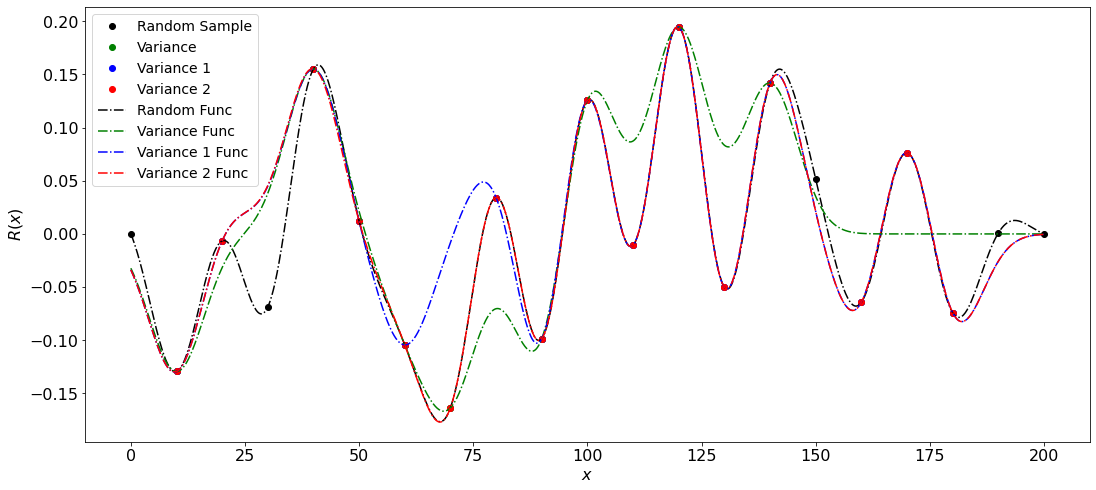

Sample size : 21
 Variance  : 38.0%
 Varaince1 : 71.43%
 Variance2 : 76.19%

Mean Absolute Error:
 Variance  : 0.0353
 Variance1 : 0.0172
 Variance2 : 0.0098


In [38]:
dv = np.array([dd for i,dd in enumerate(d) if dd > mu+var or dd < mu-var])
dv_ind = [d.tolist().index(i) for i in dv if i in d]
Xv = X[dv_ind]

dv1 = np.array([dd for i,dd in enumerate(d) if abs(dd-d[i-1])>var])
dv1_ind = [d.tolist().index(i) for i in dv1 if i in d]
Xv1 = X[dv1_ind]

dv2 = np.array([dd for i,dd in enumerate(d) if dd > mu+var or dd < mu-var or abs(dd-d[i-1])>var])
dv2_ind = [d.tolist().index(i) for i in dv2 if i in d]
Xv2 = X[dv2_ind]

# Gaussian length scale.
L = 6

# Calculate the kernel matrix G
Gv = kernel_matrix(Xv, L, gaussian)
Gv1 = kernel_matrix(Xv1, L, gaussian)
Gv2 = kernel_matrix(Xv2, L, gaussian)

# Invert d = Gm for the model parameters.
mv = rbf_model(Gv, dv)
mv1 = rbf_model(Gv1, dv1)
mv2 = rbf_model(Gv2, dv2)

# Using m, interpolate phi for all values in x ∈ [0, 1].
x = np.linspace(0, 200, 1000)
Sv = rbf_predict(x, Xv, mv, L, gaussian)
Sv1 = rbf_predict(x, Xv1, mv1, L, gaussian)
Sv2 = rbf_predict(x, Xv2, mv2, L, gaussian)

# Plot the results.
plt.figure(figsize = [18, 8])
plt.plot(X, d, "ko", label="Random Sample")     # Sampled discrete data points of phi.
plt.plot(Xv, dv, "go", label="Variance")     # Sampled discrete data points of phi.
plt.plot(Xv1, dv1, "bo", label="Variance 1")     # Sampled discrete data points of phi.
plt.plot(Xv2, dv2, "ro", label="Variance 2")     # Sampled discrete data points of phi.
plt.plot(x, S, "k-.", label="Random Func")    # # Interpolated values of phi.
plt.plot(x, Sv, "g-.", label="Variance Func")     # Sampled discrete data points of phi.
plt.plot(x, Sv1, "b-.", label="Variance 1 Func")     # Sampled discrete data points of phi.
plt.plot(x, Sv2, "r-.", label="Variance 2 Func")     # Sampled discrete data points of phi.

plt.legend(fontsize = 14)
plt.xlabel("$x$", fontsize = 16)
plt.ylabel("$R(x)$", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()


# # Plots the weighted Gaussians used in the interpolation model.
# plt.figure(1, figsize = [18, 4])
# for i in range(len(m)):
#     plt.plot(m[i] * gaussian(x, X[i], L))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

# plt.figure(2, figsize = [18, 4])
# for i in range(len(m_)):
#     plt.plot(m_[i] * gaussian(x, X_[i], L_))
# plt.legend(range(len(m)), fontsize = 14)
# plt.xlabel("$x$", fontsize = 16)
# plt.ylabel("$f(x)$", fontsize = 16)
# plt.xticks(fontsize = 16)
# plt.yticks(fontsize = 16)
# plt.show()

print(f"Sample size : {len(X)}")
print(f" Variance  : {np.round(len(Xv)/len(X),2)*100}%")
print(f" Varaince1 : {np.round(len(Xv1)/len(X)*100,2)}%")
print(f" Variance2 : {np.round(len(Xv2)/len(X)*100,2)}%")
print("")
print("Mean Absolute Error:")
print(f" Variance  : {np.round(np.mean(abs(rbf_predict(X, Xv, mv, L, gaussian)-d)),4)}")
print(f" Variance1 : {np.round(np.mean(abs(rbf_predict(X, Xv1, mv1, L, gaussian)-d)),4)}")
print(f" Variance2 : {np.round(np.mean(abs(rbf_predict(X, Xv2, mv2, L, gaussian)-d)),4)}")

# Spline Interpolation

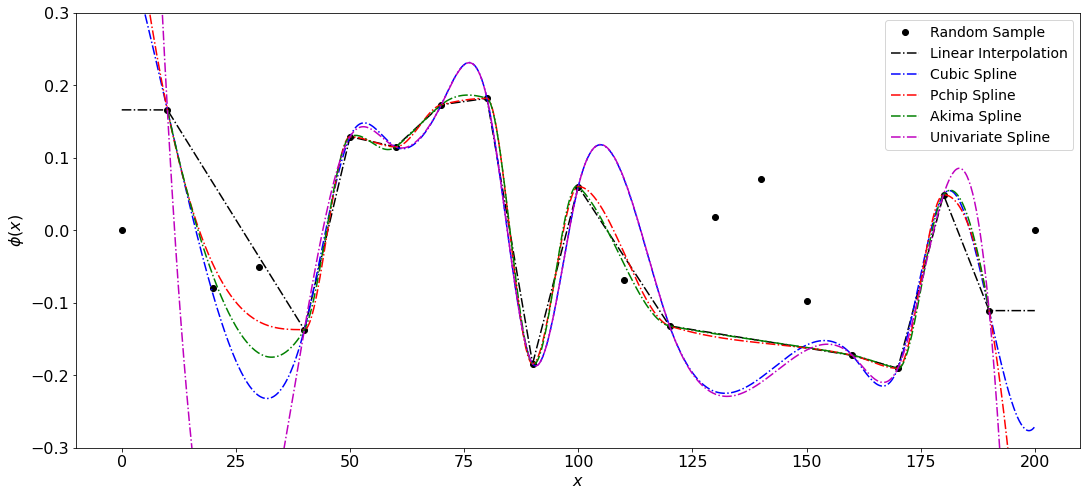

Cubic Spline: Knots = (13,), Coefficients = (4, 12)
Pchip Spline: Knots = (13,), Coefficients = (4, 12)
Akima Spline: Knots = (13,), Coefficients = (4, 12)
Univariate Spline: Knots = (11,), Coefficients = (13,)


In [6]:
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator, UnivariateSpline, splrep

X_spl, d_spl = Xv, dv
spl = CubicSpline(X_spl, d_spl, bc_type='natural')
Pspl = PchipInterpolator(X_spl, d_spl)
Aspl = Akima1DInterpolator(X_spl, d_spl)
UVspl = UnivariateSpline(X_spl, d_spl, s=0)

plt.figure(figsize = [18, 8])
plt.plot(X, d, "ko", label="Random Sample")     # Sampled discrete data points of phi.
plt.plot(x, np.interp(x, X_spl, d_spl), "k-.", label="Linear Interpolation") # True "continuous" values of phi.
plt.plot(x, spl(x), "b-.", label="Cubic Spline")    # # Interpolated values of phi.
plt.plot(x, Pspl(x), "r-.", label="Pchip Spline")     # Sampled discrete data points of phi.
plt.plot(x, Aspl(x), "g-.", label="Akima Spline")     # Sampled discrete data points of phi.
plt.plot(x, UVspl(x), "m-.", label="Univariate Spline")     # Sampled discrete data points of phi.

plt.legend(fontsize = 14)
plt.xlabel("$x$", fontsize = 16)
plt.ylabel("$\phi(x)$", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.ylim(-0.3, 0.3)
plt.show()

print(f"Cubic Spline: Knots = {spl.x.shape}, Coefficients = {spl.c.shape}")
print(f"Pchip Spline: Knots = {Pspl.x.shape}, Coefficients = {Pspl.c.shape}")
print(f"Akima Spline: Knots = {Aspl.x.shape}, Coefficients = {Aspl.c.shape}")
print(f"Univariate Spline: Knots = {UVspl.get_knots().shape}, Coefficients = {UVspl.get_coeffs().shape}")

# Lagrange Polynomials

# Taylor Expansion

# Fourier Series

# Orthogonal (Legendre) Polynomial

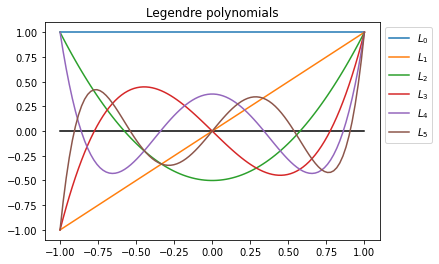

In [154]:
from scipy.special import legendre

def L(x,n):
    Leg = legendre(n)
    y = Leg(x)
    return y

xx = np.linspace(-1,1,100)
plt.plot(xx,0*xx,'k-')
for i in range(6):
    plt.plot(xx,L(xx,i),label=r'$L_'+str(i)+'$') 
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=1)  
plt.title('Legendre polynomials')
plt.show() 

# Least Squares

In [155]:
import sympy as sym

def least_squares(f, psi, Omega):
    N = len(psi) - 1
    A = sym.zeros((N+1, N+1))
    b = sym.zeros((N+1, 1))
    x = sym.Symbol('x')
    for i in range(N+1):
        for j in range(i, N+1):
            A[i,j] = sym.integrate(psi[i]*psi[j],
                                  (x, Omega[0], Omega[1]))
            A[j,i] = A[i,j]
        b[i,0] = sym.integrate(psi[i]*f, (x, Omega[0], Omega[1]))
    c = A.LUsolve(b)
    # Note: c is a sympy Matrix object, solution is in c[:,0]
    u = 0
    for i in range(len(psi)):
        u += c[i,0]*psi[i]
    return u, c

In [ ]:
def least_squares(f, psi, Omega, symbolic=True):
    N = len(psi) - 1
    A = sym.zeros((N+1, N+1))
    b = sym.zeros((N+1, 1))
    x = sym.Symbol('x')
    for i in range(N+1):
        for j in range(i, N+1):
            integrand = psi[i]*psi[j]
            if symbolic:
                I = sym.integrate(integrand, (x, Omega[0], Omega[1]))
            if not symbolic or isinstance(I, sym.Integral):
                # Could not integrate symbolically,
                # fall back on numerical integration
                integrand = sym.lambdify([x], integrand)
                I = sym.mpmath.quad(integrand, [Omega[0], Omega[1]])
            A[i,j] = A[j,i] = I

        integrand = psi[i]*f
        if symbolic:
            I = sym.integrate(integrand, (x, Omega[0], Omega[1]))
        if not symbolic or isinstance(I, sym.Integral):
            integrand = sym.lambdify([x], integrand)
            I = sym.mpmath.quad(integrand, [Omega[0], Omega[1]])
        b[i,0] = I
    c = A.LUsolve(b)  # symbolic solve
    # c is a sympy Matrix object, numbers are in c[i,0]
    c = [sym.simplify(c[i,0]) for i in range(c.shape[0])]
    u = sum(c[i]*psi[i] for i in range(len(psi)))
    return u, c

In [ ]:
def comparison_plot(f, u, Omega, filename='tmp.pdf'):
    x = sym.Symbol('x')
    f = sym.lambdify([x], f, modules="numpy")
    u = sym.lambdify([x], u, modules="numpy")
    resolution = 401  # no of points in plot
    xcoor  = linspace(Omega[0], Omega[1], resolution)
    exact  = f(xcoor)
    approx = u(xcoor)
    plot(xcoor, approx)
    hold('on')
    plot(xcoor, exact)
    legend(['approximation', 'exact'])
    savefig(filename)

In [157]:
x = sym.Symbol('x')
f = 10*(x-1)**2-1
u, c = least_squares(f=f, psi=[1, x, x**2], Omega=[1, 2])
print(u)
print(sym.expand(f))

ModuleNotFoundError: No module named 'approx1D'

# ETC


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander2d, chebval2d

# ---------------------------
# Define a sample 2D function
# ---------------------------
nx, ny = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

# Example function resembling a GP mean function output
def f(x, y):
    return np.sin(2*np.pi*x) * np.cos(2*np.pi*y) + 0.5*np.sin(4*np.pi*x) * np.cos(4*np.pi*y)

F = f(X, Y)

# ---------------------------
# 1. Fourier Series Approximation via FFT
# ---------------------------
# Compute the 2D FFT
F_fft = np.fft.fft2(F)
F_fft_shift = np.fft.fftshift(F_fft)

# Create a mask that keeps only the low-frequency components (a 10x10 block around the center)
keep = 10
mask = np.zeros_like(F_fft_shift, dtype=bool)
center_x, center_y = nx//2, ny//2
mask[center_x-keep:center_x+keep, center_y-keep:center_y+keep] = True

# Truncate the FFT coefficients and perform the inverse FFT
F_fft_truncated = np.zeros_like(F_fft_shift)
F_fft_truncated[mask] = F_fft_shift[mask]
F_fft_truncated_unshift = np.fft.ifftshift(F_fft_truncated)
F_fourier_approx = np.fft.ifft2(F_fft_truncated_unshift).real

# ---------------------------
# 2. Chebyshev Polynomial Approximation
# ---------------------------
# Chebyshev polynomials are defined on [-1, 1], so we remap x and y:
x_cheb = 2 * x - 1
y_cheb = 2 * y - 1
X_cheb, Y_cheb = np.meshgrid(x_cheb, y_cheb)

# Set degrees for the expansion in x and y
deg_x, deg_y = 10, 10

# Build the 2D Chebyshev Vandermonde matrix over the grid (flattened)
V = chebvander2d(X_cheb.ravel(), Y_cheb.ravel(), [deg_x, deg_y])

# Solve the least squares problem to obtain the Chebyshev coefficients
coeffs, _, _, _ = np.linalg.lstsq(V, F.ravel(), rcond=None)

# Reshape coefficients into a 2D array for evaluation and reconstruct the function
F_cheb_approx = chebval2d(X_cheb, Y_cheb, coeffs.reshape(deg_x+1, deg_y+1))

# ---------------------------
# 3. Taylor Series Expansion (Local, up to 2nd order)
# ---------------------------
# Choose the expansion point (e.g., the center of the domain)
x0, y0 = 0.5, 0.5
dx = x[1] - x[0]
dy = y[1] - y[0]

# Find indices near the expansion point
ix = np.argmin(np.abs(x - x0))
iy = np.argmin(np.abs(y - y0))

# Compute the function value and finite difference approximations for derivatives at (x0,y0)
f0 = F[iy, ix]
fx = (F[iy, ix+1] - F[iy, ix-1]) / (2*dx)
fy = (F[iy+1, ix] - F[iy-1, ix]) / (2*dy)
fxx = (F[iy, ix+1] - 2*F[iy, ix] + F[iy, ix-1]) / (dx**2)
fyy = (F[iy+1, ix] - 2*F[iy, ix] + F[iy-1, ix]) / (dy**2)
fxy = (F[iy+1, ix+1] - F[iy+1, ix-1] - F[iy-1, ix+1] + F[iy-1, ix-1]) / (4*dx*dy)

# Build the Taylor approximation for each grid point
F_taylor_approx = (f0 +
                   fx * (X - x0) +
                   fy * (Y - y0) +
                   0.5 * fxx * (X - x0)**2 +
                   0.5 * fyy * (Y - y0)**2 +
                   fxy * (X - x0) * (Y - y0))

# ---------------------------
# 4. Proper Orthogonal Decomposition (POD) / PCA via SVD
# ---------------------------
# For POD, we treat the 2D function F as a data matrix.
# First subtract the mean (here we compute the mean across rows)
F_mean = np.mean(F, axis=0)
F_centered = F - F_mean

# Compute the Singular Value Decomposition (SVD)
U, S, Vh = np.linalg.svd(F_centered, full_matrices=False)

# Choose a number of modes to retain; fewer modes mean a more compact approximation.
num_modes = 5
F_pod_approx = np.dot(U[:, :num_modes],
                      np.dot(np.diag(S[:num_modes]), Vh[:num_modes, :])) + F_mean

# ---------------------------
# Plotting All Approximations
# ---------------------------
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Original function
im0 = axs[0, 0].imshow(F, extent=[0, 1, 0, 1], origin='lower')
axs[0, 0].set_title("Original Function")
fig.colorbar(im0, ax=axs[0, 0])

# Fourier approximation
im1 = axs[0, 1].imshow(F_fourier_approx, extent=[0, 1, 0, 1], origin='lower')
axs[0, 1].set_title("Fourier Approximation")
fig.colorbar(im1, ax=axs[0, 1])

# Chebyshev approximation
im2 = axs[0, 2].imshow(F_cheb_approx, extent=[0, 1, 0, 1], origin='lower')
axs[0, 2].set_title("Chebyshev Approximation")
fig.colorbar(im2, ax=axs[0, 2])

# Taylor series approximation
im3 = axs[1, 0].imshow(F_taylor_approx, extent=[0, 1, 0, 1], origin='lower')
axs[1, 0].set_title("Taylor Series Approximation")
fig.colorbar(im3, ax=axs[1, 0])

# POD/PCA approximation
im4 = axs[1, 1].imshow(F_pod_approx, extent=[0, 1, 0, 1], origin='lower')
axs[1, 1].set_title("POD/PCA Approximation")
fig.colorbar(im4, ax=axs[1, 1])

# Hide the unused subplot
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()
